# Connecting Github Repository and downloading dependencies

In [1]:
!git clone https://github.com/SahilRamdoss/Real_Time_Capuchin_Detector.git

Cloning into 'Real_Time_Capuchin_Detector'...
remote: Enumerating objects: 165, done.
remote: Counting objects: 100% (165/165), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 165 (delta 67), reused 136 (delta 41), pack-reused 0 (from 0)
Receiving objects: 100% (165/165), 11.03 MiB | 13.35 MiB/s, done.
Resolving deltas: 100% (67/67), done.


In [2]:
!git fetch origin
!git reset --hard origin/main

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [ ]:
%cd /content/Real_Time_Capuchin_Detector
!git pull -f origin main

/content/Real_Time_Capuchin_Detector
From https://github.com/SahilRamdoss/Real_Time_Capuchin_Detector
 * branch            main       -> FETCH_HEAD
Updating 3af7f80..79a17d6
error: Your local changes to the following files would be overwritten by merge:
	training/data_prep/audio_normalisation.py
Please commit your changes or stash them before you merge.
Aborting


In [2]:
!pip install audiomentations pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 19.3 MB/s eta 0:00:00
  Attempting uninstall: soxr
    Found existing installation: soxr 1.1.0
    Uninstalling soxr-1.1.0:
      Successfully uninstalled soxr-1.1.0


# Obtaining file paths for Capuchin file and noise files

Creating a list of the required file paths

In [3]:
from glob import glob

CAPUCHIN_FILES_PATHS = glob(r"/content/drive/MyDrive/Datasets/data/Parsed_Capuchinbird_Clips/*.wav")
NON_CAPUCHINE_FILE_PATHS = glob(r"/content/drive/MyDrive/Datasets/data/Parsed_Not_Capuchinbird_Clips/*.wav")

print(f"Number of Capuchin files: {len(CAPUCHIN_FILES_PATHS)}")
print(f"Number of Non-Capuchin files: {len(NON_CAPUCHINE_FILE_PATHS)}")

Number of Capuchin files: 217
Number of Non-Capuchin files: 593


We are downsampling the majority class here to prevent class imbalance.

In [4]:
import random

# We are shuffling because the noise files are currently order by their types in the directory
random.shuffle(NON_CAPUCHINE_FILE_PATHS)

NON_CAPUCHINE_FILE_PATHS = NON_CAPUCHINE_FILE_PATHS[:len(CAPUCHIN_FILES_PATHS)]

print(f"Number of Capuchin files: {len(CAPUCHIN_FILES_PATHS)}")
print(f"Number of Non-Capuchin files: {len(NON_CAPUCHINE_FILE_PATHS)}")

Number of Capuchin files: 217
Number of Non-Capuchin files: 217


Add the project root in system paths

In [5]:
import os, sys

PROJECT_ROOT = "/content/Real_Time_Capuchin_Detector"

if PROJECT_ROOT not in sys.path:
  sys.path.append(PROJECT_ROOT)

Get the required constants from config.yaml file

In [6]:
import yaml

spec_cfg = None

with open(r"/content/Real_Time_Capuchin_Detector/configs/config.yaml", "r") as f:
  config = yaml.safe_load(f)

  try:
      spec_cfg = config["spec_config"]
      shared = config["shared"]
  except KeyError as e:
      raise KeyError(
          f"config.yaml is missing expected key {e}. Check that 'shared.sr' and 'spec_config' are present."
      ) from e
FILTER_ORDER = spec_cfg["filter_order"]
N_FFT = spec_cfg["n_fft"]
HOP_LENGTH = spec_cfg["hop_length"]
N_MELS = spec_cfg["n_mels"]

WINDOW_SIZE = shared["window_size"]
SR = shared["sr"]

print(f"FILTER_ORDER = {FILTER_ORDER}")
print(f"N_FFT = {N_FFT}")
print(f"HOP_LENGTH = {HOP_LENGTH}")
print(f"N_MELS = {N_MELS}")

print(f"WINDOW_SIZE = {WINDOW_SIZE}")
print(f"SR = {SR}")

FILTER_ORDER = 4
N_FFT = 256
HOP_LENGTH = 128
N_MELS = 64
WINDOW_SIZE = 3.0
SR = 24000


# Creating model architecture

In [7]:
import keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from keras.layers import Normalization, Dense, Dropout
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, Normalization, Activation

NUMBER_OF_CHANNELS = 1

def create_and_compile_model():
  base_model = Sequential([
    Conv2D(filters=32, kernel_size= (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(filters=32, kernel_size= (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    MaxPooling2D(2,2),

    Conv2D(filters=64, kernel_size=(3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Conv2D(filters=64, kernel_size=(3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    MaxPooling2D(2,2),

    Conv2D(filters=128, kernel_size=(3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
  ])

  INPUT_SHAPE = (N_MELS, int((WINDOW_SIZE * SR) // HOP_LENGTH) - 1, NUMBER_OF_CHANNELS)

  inputs = keras.Input(shape=INPUT_SHAPE)
  normalization_layer = Normalization(axis=None)

  X = normalization_layer(inputs)
  X = base_model(X)
  X = GlobalAveragePooling2D()(X)
  X = Dense(128, activation="relu")(X)
  X = Dropout(0.4)(X)
  X = Dense(128, activation="relu")(X)
  X = Dropout(0.3)(X)
  X = Dense(64, activation="relu")(X)
  X = Dropout(0.2)(X)
  X = Dense(32, activation="relu")(X)

  outputs = Dense(1, activation="sigmoid")(X)

  bird_model = keras.Model(inputs, outputs)

  bird_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
                   loss=keras.losses.BinaryCrossentropy(),
                   metrics= [
                       keras.metrics.BinaryCrossentropy()
                   ])

  return bird_model, normalization_layer

# Creating Data pipeline with k-fold cross-validation

Let us create the folds first:

In [19]:
from typing import Tuple, Optional
import numpy as np
import tensorflow as tf
import yaml
from training.data_prep.audio_normalisation import AudioNorm
from training.data_prep.audio_augmentation import AudioAug
from features.mel_spectogram_generator import MelSpectrogramGen
from training.data_prep.spec_augmentation import SpecAugment
import random
from IPython.display import display, Audio


#################################################
# Initialize constants
#################################################

K = 5
BATCH_SIZE = 16

#################################################
# Create instance of classes only once
#################################################

audio_norm = AudioNorm.from_config()
audio_aug = AudioAug()
spec_gen = MelSpectrogramGen.from_config()
spec_aug = SpecAugment.from_config()

#################################################
# Functions to be used in data pipelines
#################################################

@tf.py_function(Tout=[tf.float32, tf.int64])
def preprocess_audio_data(file_path:str, label: int) -> Tuple[np.ndarray, int]:
  raw = tf.io.read_file(file_path)
  audio, sr = tf.audio.decode_wav(raw, desired_channels=1)
  audio = tf.squeeze(audio, axis=-1).numpy()
  sr = sr.numpy()

  # Random Clipping
  audio, sr = audio_norm.random_clipping(audio, sr)
  # 1D Audio augmentation
  # audio = audio_aug.augment_audio(audio, sr)

  return audio, label


def generate_spectrogram_helper(audio: np.ndarray, label:int) -> Tuple[np.ndarray, int]:
  # Convert EagerTensor to a pure NumPy array
  if hasattr(audio, "numpy"):
      audio = audio.numpy()

  # Generate the mel-spectrogram
  spectrogram = spec_gen.generate_mel_spectrogram(audio)
  return spectrogram, label

def generate_spectrogram(audio: tf.Tensor, label: tf.Tensor):
  spectrogram, label = tf.py_function(
      func=generate_spectrogram_helper,
      inp=[audio, label],
      Tout=[tf.float32,tf.int64]
  )

  spectrogram = tf.expand_dims(spectrogram, axis=-1)

  # Shape is: [n_mels, (window_size * sr) / hop_length]
  spectrogram.set_shape([N_MELS, int(((WINDOW_SIZE * SR) // HOP_LENGTH) - 1), 1])

  label = tf.expand_dims(label, axis=-1)
  label = tf.cast(label, tf.float32)
  label.set_shape([1])

  return spectrogram, label


def spec_augment(spec: tf.Tensor , label:int, probability: Optional[float] = 0.4) -> Tuple[tf.Tensor, int]:
  do_augment = tf.random.uniform([]) <= probability

  return tf.cond(
        do_augment,
        lambda: spec_aug.augment(spec, label),
        lambda: (spec, label)
    )



#######################################################
# Main code
#######################################################

fold_ds = list()

# Calculate starts indices for different folds
start_indices = []
fold_size = (len(CAPUCHIN_FILES_PATHS) + len(NON_CAPUCHINE_FILE_PATHS)) // K
start_index = 0

# Generate the start indices for the folds
for i in range(0, K):
  start_indices.append(start_index)
  start_index += fold_size

for i in range(0, len(start_indices)):
  start_indices[i] = start_indices[i] // 2


for i in range(0,K):
  # Creating the folds
  start_index = start_indices[i]

  if i < (K - 1):
    end_index = start_indices[i + 1]
    capuchin_fold = CAPUCHIN_FILES_PATHS[start_index:end_index]
    non_capuchin_fold = NON_CAPUCHINE_FILE_PATHS[start_index:end_index]
  else:
    capuchin_fold = CAPUCHIN_FILES_PATHS[start_index:]
    non_capuchin_fold = NON_CAPUCHINE_FILE_PATHS[start_index:]

  # Generate labels
  capuchin_labels = np.array([1] * len(capuchin_fold))
  non_capuchin_labels = np.array([0] * len(non_capuchin_fold))

  # Converting folds to dataset
  capuchin_ds = tf.data.Dataset.from_tensor_slices((capuchin_fold, capuchin_labels))
  noise_ds = tf.data.Dataset.from_tensor_slices((non_capuchin_fold, non_capuchin_labels))

  # Applying preprocessing to capuchin dataset
  capuchin_ds = (
      capuchin_ds
      .map(preprocess_audio_data, num_parallel_calls=tf.data.AUTOTUNE)
  )

  # Applying preprocessing to noise dataset
  noise_ds = (
      noise_ds
      .map(preprocess_audio_data, num_parallel_calls = tf.data.AUTOTUNE)
  )

  # Combine both datasets.
  # tf.data.Dataset.sample_from_datasets picks the next file
  # in either of the dataset with a 50.50 probability. Since,
  # the non-capuchin files had already been shuffled and the order
  # does not matter for Capuchin calls, re-shuffling is not needed
  combined_ds = tf.data.Dataset.sample_from_datasets(
      [capuchin_ds, noise_ds],
      weights=[0.5,0.5]
  )

  combined_ds = (
      combined_ds
      # generate_spectrogram is a tf.py_function
      .map(generate_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)
  )

  fold_ds.append(combined_ds)

print(f"Folds: {fold_ds}")
print(f"Number of folds: {len(fold_ds)}")

Folds: [<_ParallelMapDataset element_spec=(TensorSpec(shape=(64, 561, 1), dtype=tf.float32, name=None), TensorSpec(shape=(1,), dtype=tf.float32, name=None))>, <_ParallelMapDataset element_spec=(TensorSpec(shape=(64, 561, 1), dtype=tf.float32, name=None), TensorSpec(shape=(1,), dtype=tf.float32, name=None))>, <_ParallelMapDataset element_spec=(TensorSpec(shape=(64, 561, 1), dtype=tf.float32, name=None), TensorSpec(shape=(1,), dtype=tf.float32, name=None))>, <_ParallelMapDataset element_spec=(TensorSpec(shape=(64, 561, 1), dtype=tf.float32, name=None), TensorSpec(shape=(1,), dtype=tf.float32, name=None))>, <_ParallelMapDataset element_spec=(TensorSpec(shape=(64, 561, 1), dtype=tf.float32, name=None), TensorSpec(shape=(1,), dtype=tf.float32, name=None))>]
Number of folds: 5


Now, let us create the training loop

In [ ]:
for fold_number in range(K):
  val_fold = fold_ds[fold_number]
  train_folds = [fold for index, fold in enumerate(fold_ds) if index != fold_number]

  train_ds = train_folds[0]
  for fold in train_folds[1:]:
    train_ds = train_ds.concatenate(fold)

  train_ds = (
      train_ds
      .shuffle(buffer_size=1000)
      .map(spec_augment, num_parallel_calls=tf.data.AUTOTUNE)
      .batch(batch_size=BATCH_SIZE, drop_remainder=True)
      .prefetch(buffer_size=tf.data.AUTOTUNE)
  )

  val_ds = (
      val_fold
      .batch(batch_size=BATCH_SIZE, drop_remainder=True)
      .prefetch(buffer_size=tf.data.AUTOTUNE)
  )

  # Initialize model weights
  bird_model, normalization_layer = create_and_compile_model()

  # Set mean and variance for normalization layer
  normalization_layer.adapt(data=train_ds.map(lambda spec, _ : spec))

  print(f"Training Iteration: {fold_number}")

  bird_model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=12,
      callbacks = [
          keras.callbacks.EarlyStopping(
              monitor="val_loss",
              patience=3,
              restore_best_weights= True
          )
      ]
  )

Training Iteration: 0
Epoch 1/12
     21/Unknown 18s 51ms/step - binary_crossentropy: 0.6930 - loss: 0.6930

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - binary_crossentropy: 0.6817 - loss: 0.6817 - val_binary_crossentropy: 0.6932 - val_loss: 0.6932
Epoch 2/12
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 309ms/step - binary_crossentropy: 0.6596 - loss: 0.6596 - val_binary_crossentropy: 0.6929 - val_loss: 0.6929
Epoch 3/12
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 141ms/step - binary_crossentropy: 0.6226 - loss: 0.6226 - val_binary_crossentropy: 0.6916 - val_loss: 0.6916
Epoch 4/12
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 192ms/step - binary_crossentropy: 0.5808 - loss: 0.5808 - val_binary_crossentropy: 0.6882 - val_loss: 0.6882
Epoch 5/12
21/21 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - binary_crossentropy: 0.5560 - loss: 0.5560 - val_binary_crossentropy: 0.6887 - val_loss: 0.6887
Epoch 6/12
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - binary_crossentropy: 0.4956 - loss: 0.4956 - val_binary_crossentropy: 0.6981 - val_loss: 0.6981
Epoch 7/12
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - binary_crossentropy: 0.4790 - loss: 0.4790 - val_bina

# Testing

## Testing tensorflow dataset

Label: 1


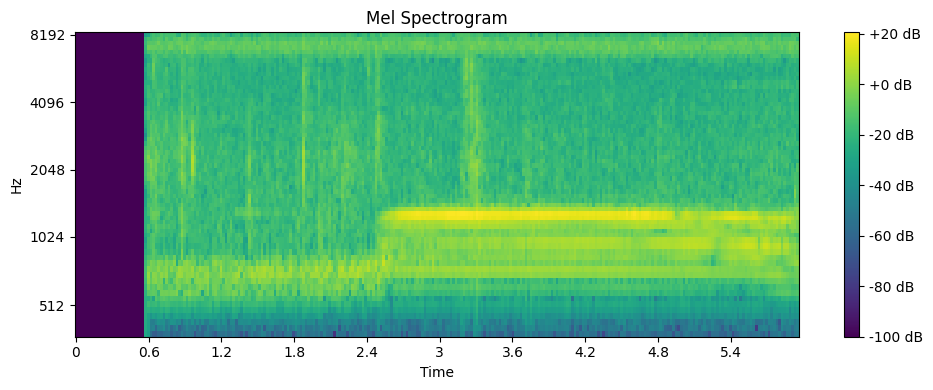

Label: 1


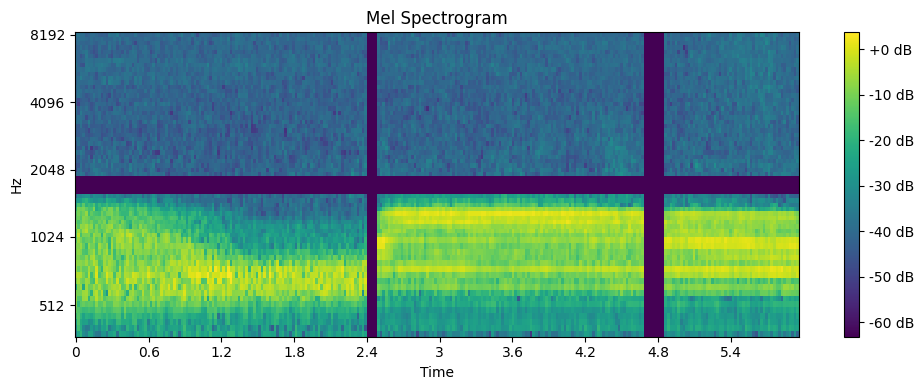

Label: 1


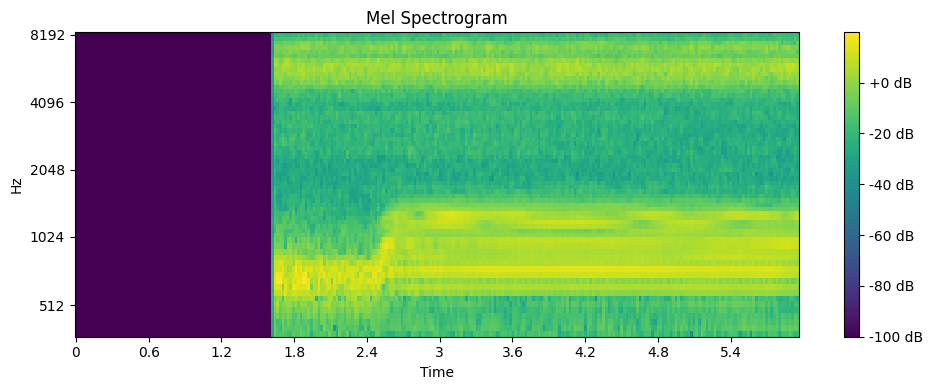

Label: 1


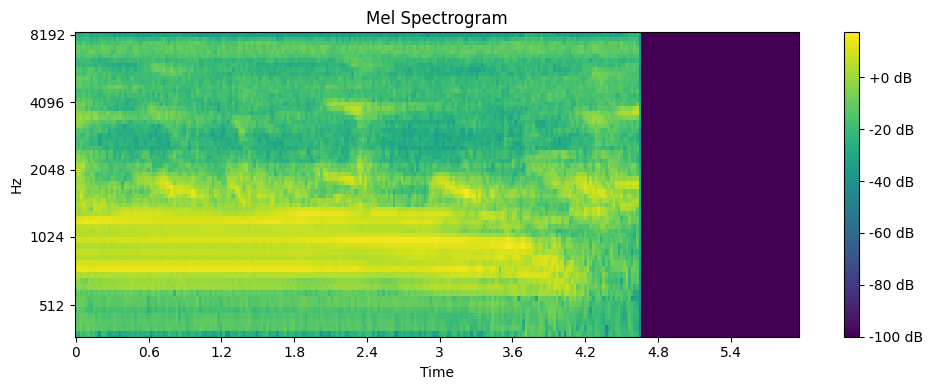

In [43]:
import librosa
import matplotlib.pyplot as plt
import numpy
from IPython.display import display, Audio


for spectrogram_batch, label_batch in combined_ds.take(4):
  single_spec = spectrogram_batch[0].numpy()
  single_label = label_batch[0].numpy()

  print(f"Label: {single_label}")

  # plot spectrogram
  plt.figure(figsize=(10, 4))
  librosa.display.specshow(single_spec, sr=24000, x_axis='time', y_axis='mel', cmap='viridis',  fmin=300, fmax=8200)

  # Add UI elements
  plt.colorbar(format='%+2.0f dB')
  plt.title('Mel Spectrogram')
  plt.tight_layout()

  # 5. Display the plot
  plt.show()